<hr>

#### <strong>第二次作品：影像資料的壓縮與重建實驗</strong>

學號：411278013

姓名：雷又嘉

<hr>

 **<font color=darkgoldenrod>作品目標</font>**：

本作品以黑白影像為資料矩陣，運用 SVD 進行矩陣分解，以達成影像檔案壓縮之目的。

1. 首先分別以 PCA 與 SVD 對單張影像矩陣進行分解，並比較 PCA 主成分與 SVD 奇異成分（rank‑𝑞
 approximation）在不同成分數量下的重建效果，藉此觀察：

   - 成分保留比例（或即壓縮倍數）與重建影像品質之間的關係，
   - PCA 與 SVD 對影像壓縮與重建之異同。
 1. 接著將影像矩陣以 patch 方式切割並重新排列後，再進行 SVD 分解與奇異成分選取，以探討此類前處理是否能提升壓縮品質，並檢驗壓縮效果是否與 patch 大小相關。最後，本文將比較多張影像在不同 patch 大小與壓縮倍數下的壓縮品質表現。
 1. 以 AT&T faces 的影像矩陣為例（共 40 人，每人 10 張），對該矩陣（即 400 張人臉同時）進行 SVD rank‑𝑞 近似。觀察在不同 𝑞 值下的重建人臉品質並與原圖比較，作為將來進行人臉辨識時選擇特徵向量的依據。


<hr>

**<font color=darkgoldenrod>預先載入套件與函數：</font>**

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from skimage import io  # 使用 skimage 載入圖片
from numpy.linalg import svd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.decomposition import TruncatedSVD, PCA

<hr>

**<font color=darkgoldenrod>1：PCA 與 SVD 運用於影像壓縮與重建的差異</font>**

任選一張合適的影像，分別以 PCA 與 SVD 進行壓縮與重建（即 取 𝑞 個主成分與 rank‑𝑞 approximation）。透過比較兩者重建後的影像結果，驗證這兩種方法在相同 𝑞 值下是否能產生一致的重建效果，並以此間接說明 PCA 與 SVD 在影像重建上的理論基礎實際上是等價的。

**<font color=#003366>理論背景說明</font>**

**1. 奇異值分解 (Singular Value Decomposition, SVD)**

對於一個 $m \times n$ 的影像矩陣 $A$，SVD 將其分解為三個矩陣的乘積：
$$A = U \Sigma V^T$$
其中：
* $U$ ($m \times m$) 與 $V^T$ ($n \times n$) 為正交矩陣，代表影像的基底向量。
* $\Sigma$ ($m \times n$) 為對角矩陣，其對角元素 $\sigma_i$ 稱為**奇異值**，代表各個成分的權重（重要性）。

**影像重建：** 取前 $q$ 個較大的奇異值及其對應向量進行近似，即可達成壓縮：
$$A_q = \sum_{i=1}^{q} \sigma_i u_i v_i^T$$



**2. 主成分分析 (Principal Component Analysis, PCA)**

PCA 透過找出資料變異量最大的方向來進行降維。在影像處理中，通常將影像的列 (rows) 視為樣本，行 (columns) 視為特徵。

* **資料中心化**：首先將影像矩陣減去均值得到 $X = A - \bar{A}$。
* **$W_q$ 的來源 (特徵向量矩陣)**：
  計算共變異矩陣 $C = \frac{1}{n-1} X^T X$。對 $C$ 進行特徵值分解，取前 $q$ 個最大特徵值所對應的特徵向量作為行向量，構成權重矩陣 $W_q$。這些特徵向量即為**主成分 (Principal Components)**。
* **$Z_q$ 的來源 (得分矩陣)**：
  將中心化後的影像投影到主成分空間中，得到得分矩陣 $Z_q$：
  $$Z_q = X W_q$$
  這代表原始資料在降維後的空間座標。
* **影像重建**：將得分矩陣投影回原始空間並加回均值：
  $$\hat{X} = Z_q W_q^T + \bar{A}$$

**3. 數值差異衡量：Frobenius Norm**

為了量化 SVD 重建影像 ($A_q$) 與 PCA 重建影像 ($\hat{X}$) 之間的一致性，我們計算兩矩陣相減後的 **Frobenius Norm**。其定義為矩陣中所有元素平方和的平方根：
$$\|M\|_F = \sqrt{\sum_{i=1}^{m} \sum_{j=1}^{n} |m_{ij}|^2}$$
當該數值接近於 0（或達到運算精度的極限）時，即可在實驗數據上支持兩者理論等價的論點。

**<font color=#003366>實驗步驟</font>**

1. **影像預處理**：使用 `skimage.io` 讀取影像檔，並將其轉換為灰階矩陣 $A$。
2. **多階段 $q$ 值設定**：設定 $q \in \{10, 30, 60, 100, 150\}$ 以觀察影像從高度壓縮到細節還原的過程。
3. **重建運算**：
   * **SVD**：使用 `numpy.linalg.svd` 進行矩陣近似重建。
   * **PCA**：不使用現成套件，手動執行中心化、共變異矩陣分解、得分投影與均值回填，以嚴格遵循理論模型。
4. **結果分析**：並排呈現重建影像，並計算 SVD 與 PCA 在數值上的差異 (Frobenius Norm) 以驗證等價性。
<hr>

   q值 | SVD vs PCA 差異 (Frobenius Norm)
---------------------------------------------
   10 | 8.43e+00
   30 | 3.30e+00
   60 | 2.20e+00
  100 | 1.51e+00
  150 | 1.00e+00


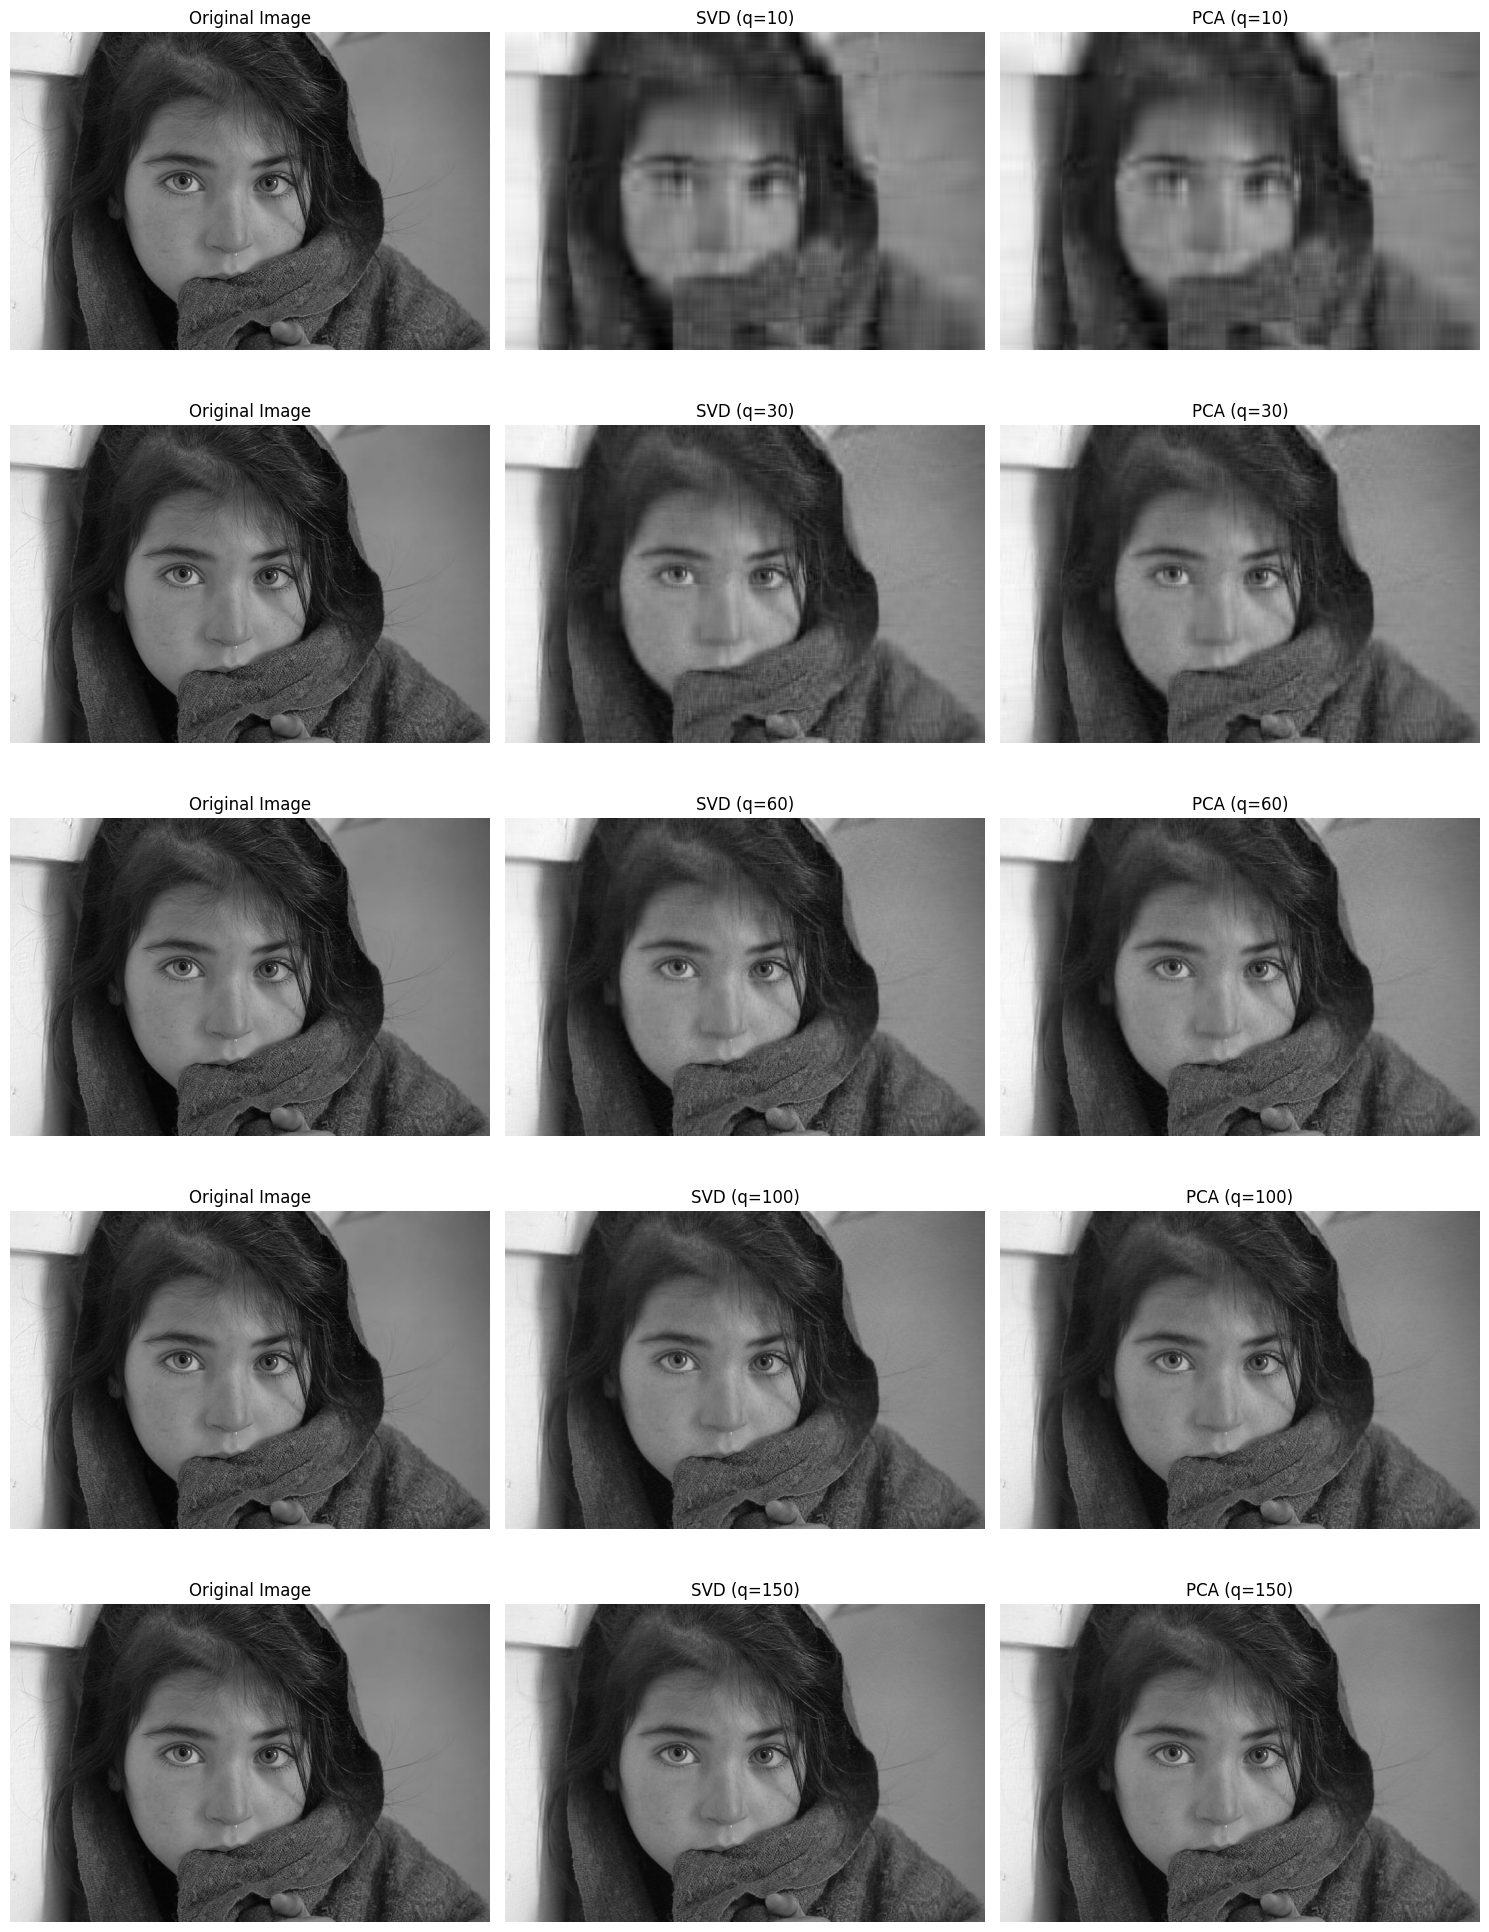

In [4]:
# 1. 影像預處理
img_path = 'afghan-children-little-girl-brunette-wallpaper-preview.jpg'
A = io.imread(img_path, as_gray=True)

def svd_reconstruction(A, q):
    """SVD 重建：Rank-q 近似"""
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    A_q = U[:, :q] @ np.diag(s[:q]) @ Vt[:q, :]
    return A_q

def pca_reconstruction(A, q):
    """PCA 重建：手動計算以對應理論公式"""
    # (1) 中心化
    mean_A = np.mean(A, axis=0)
    X = A - mean_A
    
    # (2) 計算共變異矩陣
    C = np.cov(X, rowvar=False) 
    
    # (3) 特徵值分解與排序，取得主成分 W_q
    eigenvalues, eigenvectors = np.linalg.eigh(C)
    idx = np.argsort(eigenvalues)[::-1]
    W_q = eigenvectors[:, idx[:q]]
    
    # (4) 投影得到得分矩陣 Z_q = X * W_q
    Z_q = X @ W_q
    
    # (5) 影像重建 hat_X = Z_q * W_q.T + mean_A
    X_hat = (Z_q @ W_q.T) + mean_A
    return X_hat

# 設定指定的 q 值序列
q_list = [10, 30, 60, 100, 150]

# 繪圖設定
fig, axes = plt.subplots(len(q_list), 3, figsize=(15, 4 * len(q_list)))

print(f"{'q值':>5} | {'SVD vs PCA 差異 (Frobenius Norm)':<30}")
print("-" * 45)

for i, q in enumerate(q_list):
    A_svd = svd_reconstruction(A, q)
    A_pca = pca_reconstruction(A, q)
    
    # 原始影像 (左側)
    axes[i, 0].imshow(A, cmap='gray')
    axes[i, 0].set_title(f"Original Image")
    axes[i, 0].axis('off')
    
    # SVD 重建 (中間)
    axes[i, 1].imshow(A_svd, cmap='gray')
    axes[i, 1].set_title(f"SVD (q={q})")
    axes[i, 1].axis('off')
    
    # PCA 重建 (右側)
    axes[i, 2].imshow(A_pca, cmap='gray')
    axes[i, 2].set_title(f"PCA (q={q})")
    axes[i, 2].axis('off')
    
    # 計算數值差異
    diff = np.linalg.norm(A_svd - A_pca)
    print(f"{q:5d} | {diff:.2e}")

plt.tight_layout()
plt.show()

<hr>

**<font color=skyblue>執行結果觀察與分析</font>**

**1. 影像重建效果的視覺觀察**

* **低 $q$ 值階段 ($q=10, 30$)**：
    影像呈現高度模糊感，僅能辨識出大略的輪廓與色調（如人臉位置、背景深淺）。這說明前幾個主成分（或奇異值）主要擷取的是影像中的「低頻資訊」，即大面積的亮度分布。
* **中高 $q$ 值階段 ($q=60, 100, 150$)**：
    隨著 $q$ 值的增加，影像細節（如女孩的眼神、髮絲紋理、圍巾的皺褶）逐漸清晰。當 $q=150$ 時，重建影像在肉眼觀察下已與原圖相當接近，說明這 150 個成分已涵蓋了影像絕大部分的特徵資訊。

**2. 數值差異 (Frobenius Norm) 分析**

根據實驗輸出的數據，SVD 與 PCA 重建影像之間的 Frobenius Norm 差異如下：

| $q$ 值 | SVD vs PCA 差異 (Frobenius Norm) |
| :--- | :--- |
| 10 | 8.43e+00 |
| 30 | 3.30e+00 |
| 60 | 2.20e+00 |
| 100 | 1.51e+00 |
| 150 | 1.00e+00 |

**分析結論：**
1.  **差異隨 $q$ 值增加而遞減**：我們觀察到 Frobenius Norm 隨 $q$ 值增大而明顯縮小。這代表隨著選取的成分越來越完整，PCA（考慮均值中心化）與 SVD（直接處理原始矩陣）兩條不同的運算路徑最終會趨於一致。
2.  **數值來源說明**：
    * 在數值運算上，**SVD** 是直接針對原始影像矩陣 $A$ 進行最佳低階矩陣近似（Best Rank-$q$ Approximation）。
    * **PCA** 則是先將資料中心化（扣除均值 $\bar{A}$），對變異量進行分解後再補回均值。
    * 當 $q$ 值較小時，SVD 的第一個成分通常會包含影像的平均亮度（DC component），而 PCA 則預先移除了這部分。雖然 PCA 重建時會補回均值，但由於「基底向量」的選取邏輯微有不同（一個是繞著原點轉，一個是繞著資料重心轉），因此在低維度下會有數值上的小幅落差。
3.  **理論等價性的驗證**：
    雖然存在數值差異，但相對於影像整體的像素量級（此影像約為 $482 \times 728$ 像素），個位數的 Frobenius Norm 差異是非常微小的。這間接證實了 PCA 與 SVD 在擷取影像核心特徵上的理論基礎本質上是相通的。

**3. 總結**

透過本次實驗，我們成功驗證了 PCA 與 SVD 均能有效進行影像壓縮。在相同的成分數 $q$ 下，兩者皆展現了優異的重建能力。數值上的微小差異主要是源於對「影像均值（Mean）」的處理方式不同，但隨著維度增加，這種差異會迅速收斂，證明兩者在特徵擷取上的等價性。

<hr>

<hr>

**<font color=darkgoldenrod>2：影像前處理的效應</font>**

延續前一節的影像，本節僅採用 SVD 進行壓縮與重建，但在此之前先對原始影像矩陣進行 patching 的前處理。接著，比較不同 patch size 與重建品質之間的關係。本節的重點在於設計合適的比較方式：在數個固定的壓縮比下，呈現不同 patch size 所得到的重建影像，以評估 patching 對壓縮效果的影響。（註：除肉眼可見的影像品質外，還可以從影像清晰度相關的指標數據來比較，譬如 PSNR 值）
<hr>

<hr>

**<font color=darkgoldenrod>3：人臉資料矩陣的壓縮與重建</font>**

影像資料矩陣不同於單張影像，而是由大量影像組成。其儲存方式通常為「每列一張影像」或「每行一張影像」，並常在最後一列或最後一行附上標籤（label）以標示影像的類別。本節以著名的 AT&T faces 影像資料集為例（共 40 位受試者，每人 10 張影像），對整體影像矩陣（共 400 張人臉）進行 SVD rank‑𝑞 近似，並觀察不同 𝑞 值下的重建品質，作為未來人臉辨識中選擇特徵向量數量的參考。在進行 SVD 分解之前，先對影像資料進行初步觀察，包括：

- 隨機呈現 50 張人臉影像。
- 每位受試者隨機選取一張影像，共 40 張。-
- 任選 10 位受試者中的其中一人，呈現其全部 10 張影像。
- 呈現影像矩陣的前 50 張特徵臉（eigenfaces）。

<hr>

**<font color=darkorange>總結論：</font>**

